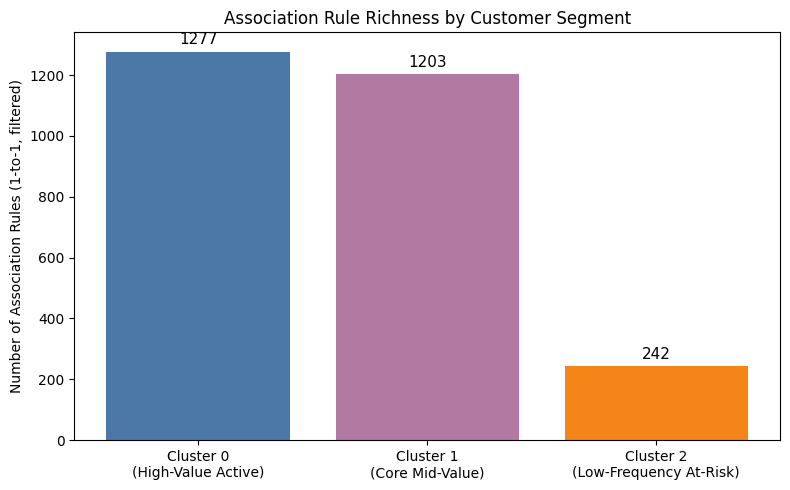

In [1]:
import matplotlib.pyplot as plt

segments = ['Cluster 0\n(High-Value Active)', 
            'Cluster 1\n(Core Mid-Value)', 
            'Cluster 2\n(Low-Frequency At-Risk)']
rule_counts = [1277, 1203, 242]
household_counts = [286, 1660, 554]
basket_counts = [79089, 181887, 14563]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(segments, rule_counts, color=['#4C78A8', '#B279A2', '#F58518'])

for bar, count in zip(bars, rule_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, 
            f'{count}', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Number of Association Rules (1-to-1, filtered)')
ax.set_title('Association Rule Richness by Customer Segment')

plt.tight_layout()
plt.savefig('figure_rules_by_segment.png', dpi=300, bbox_inches='tight')
plt.show()

c:\Users\15195\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


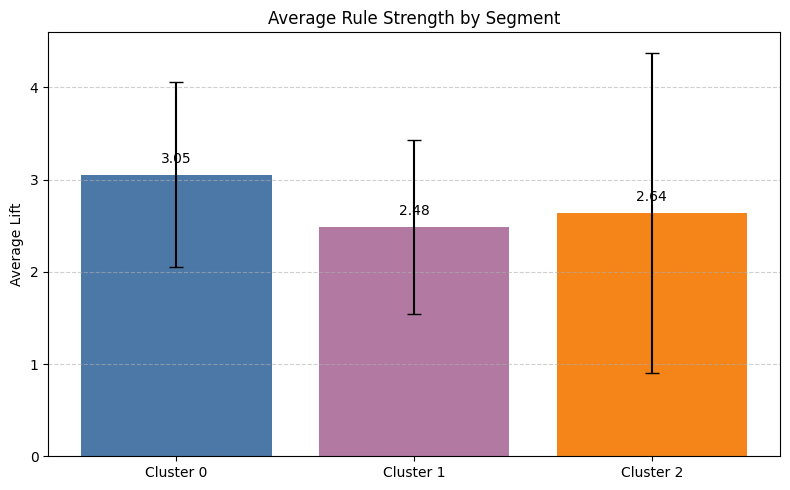

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

rules = pd.read_csv("C:/Users/15195/Desktop/coding part/coding part/Apriori part/segment_association_rules.csv")

# Calculate the statistics for each segment
stats = rules.groupby('cluster')['lift'].agg(['mean', 'std', 'count']).reset_index()
stats.columns = ['cluster', 'avg_lift', 'std_lift', 'count']
stats['segment'] = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(stats['segment'], stats['avg_lift'], 
              yerr=stats['std_lift'], capsize=5,
              color=['#4C78A8', '#B279A2', '#F58518'])

for bar, row in zip(bars, stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row.avg_lift:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Average Lift')
ax.set_title('Average Rule Strength by Segment')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('figure_avg_lift_by_segment.png', dpi=300, bbox_inches='tight')
plt.show()